In [56]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

# Step 1: Download and Load the Dataset

- This step downloads the "Adult Income" dataset from the UCI Machine Learning Repository.
- The dataset is loaded into a Pandas DataFrame and given meaningful column names.
- Missing values are marked as NaN for easier handling in preprocessing.

In [57]:
def load_dataset():
    url = "https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data"
    column_names = [
        "age", "workclass", "fnlwgt", "education", "education-num", "marital-status",
        "occupation", "relationship", "race", "sex", "capital-gain", "capital-loss",
        "hours-per-week", "native-country", "income"
    ]
    df = pd.read_csv(url, header=None, names=column_names, na_values=" ?", skipinitialspace=True)
    return df

# Load dataset
raw_data = load_dataset()
print("Dataset Head:")
print(raw_data.head())

Dataset Head:
   age         workclass  fnlwgt  education  education-num  \
0   39         State-gov   77516  Bachelors             13   
1   50  Self-emp-not-inc   83311  Bachelors             13   
2   38           Private  215646    HS-grad              9   
3   53           Private  234721       11th              7   
4   28           Private  338409  Bachelors             13   

       marital-status         occupation   relationship   race     sex  \
0       Never-married       Adm-clerical  Not-in-family  White    Male   
1  Married-civ-spouse    Exec-managerial        Husband  White    Male   
2            Divorced  Handlers-cleaners  Not-in-family  White    Male   
3  Married-civ-spouse  Handlers-cleaners        Husband  Black    Male   
4  Married-civ-spouse     Prof-specialty           Wife  Black  Female   

   capital-gain  capital-loss  hours-per-week native-country income  
0          2174             0              40  United-States  <=50K  
1             0             

# Step 2: Preprocess the Dataset

- **Dropping Missing Values:** Ensures the dataset is clean and ready for training.
- **Encoding Categorical Variables:** Converts non-numerical columns into numeric format using `LabelEncoder`, which is necessary for ML models to process categorical data.
- **Feature-Target Separation:** Splits the data into features (X) and the target variable (y).
- **Standardization:** Scales numerical features to have zero mean and unit variance, which helps the model converge faster during training.
- **Train-Test Split:** Divides the dataset into training and test sets for model evaluation.

In [58]:
def preprocess_dataset(df):
    # Drop rows with missing values
    df = df.dropna()

    # Encode categorical variables
    label_encoders = {}
    for column in df.select_dtypes(include=["object"]):
        label_encoders[column] = LabelEncoder()
        df[column] = label_encoders[column].fit_transform(df[column])

    # Separate features and target
    X = df.drop("income", axis=1)
    y = df["income"]

    # Standardize numeric features
    scaler = StandardScaler()
    X = scaler.fit_transform(X)

    return X, y

X, y = preprocess_dataset(raw_data)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 3: Define the MLP using PyTorch

- **Model Architecture:**
  - The MLP has an input layer, one hidden layer, and an output layer.
  - `ReLU` is used in the hidden layer to introduce non-linearity and help the model learn complex patterns.
  - `Sigmoid` is applied at the output layer to produce probabilities for binary classification.
- **`forward` Method:** Specifies how the input data flows through the layers during a forward pass.

In [59]:
class MLP(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super(MLP, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, output_dim),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.model(x)

# Step 4: Train the MLP

- **Model Initialization:**
  - `input_dim`, `hidden_dim`, and `output_dim` define the dimensions of the input features, hidden layer, and output.
- **Loss Function:** `BCELoss` is used for binary classification tasks.
- **Optimizer:** `SGD` adjusts weights to minimize the loss, with a learning rate of 0.1.
- **Training Loop:**
  - Performs forward and backward passes for 1000 epochs.
  - Tracks and minimizes the loss through gradient descent.
- **Visualization:** Plots the training loss over epochs to monitor convergence.


Epoch 100/1000, Loss: 0.4404
Epoch 200/1000, Loss: 0.3935
Epoch 300/1000, Loss: 0.3775
Epoch 400/1000, Loss: 0.3661
Epoch 500/1000, Loss: 0.3567
Epoch 600/1000, Loss: 0.3493
Epoch 700/1000, Loss: 0.3435
Epoch 800/1000, Loss: 0.3393
Epoch 900/1000, Loss: 0.3363
Epoch 1000/1000, Loss: 0.3343


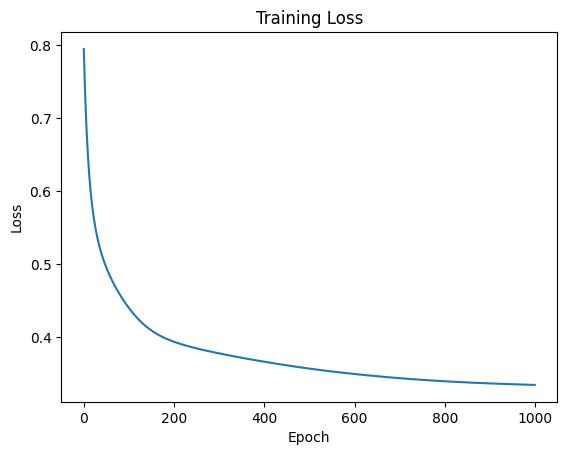

In [60]:
input_dim = X_train.shape[1]
hidden_dim = 10
output_dim = 1

mlp = MLP(input_dim, hidden_dim, output_dim)
criterion = nn.BCELoss()
optimizer = optim.SGD(mlp.parameters(), lr=0.1)

# Convert data to PyTorch tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).view(-1, 1)

epochs = 1000
losses = []

for epoch in range(epochs):
    # Forward pass
    outputs = mlp(X_train_tensor)
    loss = criterion(outputs, y_train_tensor)
    losses.append(loss.item())

    # Backward pass
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if (epoch + 1) % 100 == 0:
        print(f"Epoch {epoch + 1}/{epochs}, Loss: {loss.item():.4f}")

# Plot training loss
plt.plot(losses)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

# Step 5: Evaluate the MLP
- **Evaluation Function:**
  - Sets the model to evaluation mode using `model.eval()`.
  - Makes predictions by thresholding the output probabilities at 0.5 for binary classification.
  - Calculates accuracy by comparing predictions to actual labels.
- **Results:** Displays accuracy for both training and test datasets to assess model performance.

In [61]:
def evaluate_model(model, X, y):
    model.eval()
    with torch.no_grad():
        predictions = model(X) > 0.5
        accuracy = torch.mean((predictions == y).float()).item()
    return accuracy

train_accuracy = evaluate_model(mlp, X_train_tensor, y_train_tensor)
test_accuracy = evaluate_model(mlp, X_test_tensor, y_test_tensor)

print(f"Training Accuracy: {train_accuracy:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

Training Accuracy: 0.8433
Test Accuracy: 0.8463


# Formative Lab Exercise Questions
Explore the notebook to answer the following questions
## 1.) Effect of Neurons

**What happens to the performance of the neural network when more neurons are added to the hidden layer?**

### First Experiement
  - `hidden_dim` is set to 25. 
  - Training accuracy showed small improvement on training accuracy (from 0.8433 to 0.8434).
  - Test accuracy showed small improvement (from 0.8463 to 0.8474).
  - Loss showed small improvement (from 0.3343 to 0.3331).
  - Execution time is longer, from 1.5 seconds to 2.8 seconds.

Epoch 100/1000, Loss: 0.4265
Epoch 200/1000, Loss: 0.3883
Epoch 300/1000, Loss: 0.3714
Epoch 400/1000, Loss: 0.3603
Epoch 500/1000, Loss: 0.3520
Epoch 600/1000, Loss: 0.3457
Epoch 700/1000, Loss: 0.3410
Epoch 800/1000, Loss: 0.3376
Epoch 900/1000, Loss: 0.3350
Epoch 1000/1000, Loss: 0.3331


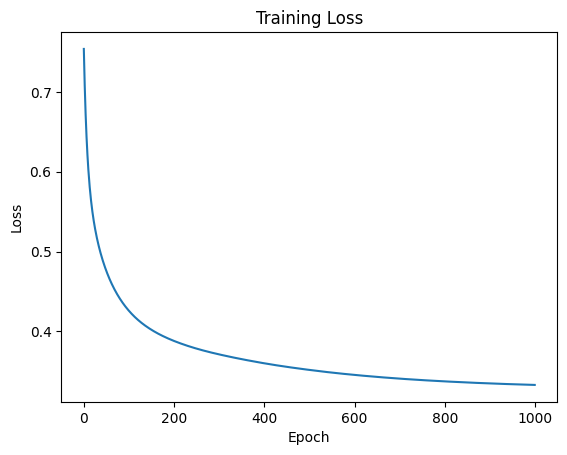

Training Accuracy: 0.8434
Test Accuracy: 0.8474


In [62]:
input_dim = X_train.shape[1]
hidden_dim = 25
output_dim = 1

mlp = MLP(input_dim, hidden_dim, output_dim)
criterion = nn.BCELoss()
optimizer = optim.SGD(mlp.parameters(), lr=0.1)

# Convert data to PyTorch tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).view(-1, 1)

epochs = 1000
losses = []

for epoch in range(epochs):
    # Forward pass
    outputs = mlp(X_train_tensor)
    loss = criterion(outputs, y_train_tensor)
    losses.append(loss.item())

    # Backward pass
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if (epoch + 1) % 100 == 0:
        print(f"Epoch {epoch + 1}/{epochs}, Loss: {loss.item():.4f}")

# Plot training loss
plt.plot(losses)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

# MLP Evaluation
def evaluate_model(model, X, y):
    model.eval()
    with torch.no_grad():
        predictions = model(X) > 0.5
        accuracy = torch.mean((predictions == y).float()).item()
    return accuracy

train_accuracy = evaluate_model(mlp, X_train_tensor, y_train_tensor)
test_accuracy = evaluate_model(mlp, X_test_tensor, y_test_tensor)

print(f"Training Accuracy: {train_accuracy:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

### Second Experiement
  - `hidden_dim` is set to 50. 
  - Training accuracy showed small improvement on training accuracy (from 0.8434 to 0.8468).
  - Test accuracy showed a bit significant improvement (from 0.8474 to 0.8523).
  - Loss showed a bit significant improvement (from 0.3331 to 0.3278).
  - Execution time is longer, from 2.8 seconds to 4.7 seconds.

Epoch 100/1000, Loss: 0.4069
Epoch 200/1000, Loss: 0.3777
Epoch 300/1000, Loss: 0.3624
Epoch 400/1000, Loss: 0.3514
Epoch 500/1000, Loss: 0.3432
Epoch 600/1000, Loss: 0.3375
Epoch 700/1000, Loss: 0.3336
Epoch 800/1000, Loss: 0.3310
Epoch 900/1000, Loss: 0.3291
Epoch 1000/1000, Loss: 0.3278


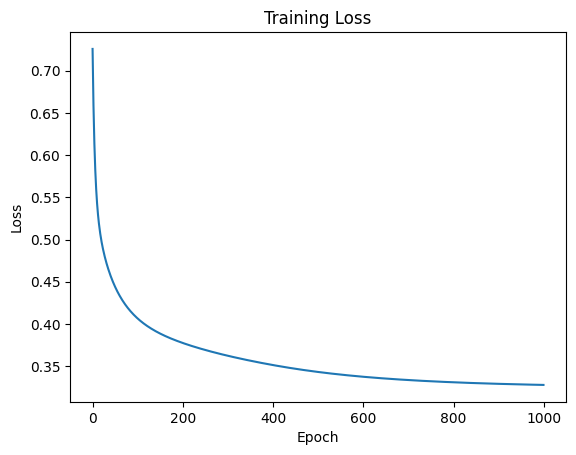

Training Accuracy: 0.8468
Test Accuracy: 0.8523


In [63]:
input_dim = X_train.shape[1]
hidden_dim = 50
output_dim = 1

mlp = MLP(input_dim, hidden_dim, output_dim)
criterion = nn.BCELoss()
optimizer = optim.SGD(mlp.parameters(), lr=0.1)

# Convert data to PyTorch tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).view(-1, 1)

epochs = 1000
losses = []

for epoch in range(epochs):
    # Forward pass
    outputs = mlp(X_train_tensor)
    loss = criterion(outputs, y_train_tensor)
    losses.append(loss.item())

    # Backward pass
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if (epoch + 1) % 100 == 0:
        print(f"Epoch {epoch + 1}/{epochs}, Loss: {loss.item():.4f}")

# Plot training loss
plt.plot(losses)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

# MLP Evaluation
def evaluate_model(model, X, y):
    model.eval()
    with torch.no_grad():
        predictions = model(X) > 0.5
        accuracy = torch.mean((predictions == y).float()).item()
    return accuracy

train_accuracy = evaluate_model(mlp, X_train_tensor, y_train_tensor)
test_accuracy = evaluate_model(mlp, X_test_tensor, y_test_tensor)

print(f"Training Accuracy: {train_accuracy:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

### Third Experiement
  - `hidden_dim` is set to 75. 
  - Training accuracy showed no improvement on training accuracy (from 0.8468 to 0.8466).
  - Test accuracy showed no improvement (from 0.8523 to 0.8506).
  - Loss showed no improvement (from 0.3278 to 0.3292).
  - Execution time is longer, from 4.7 seconds to 6.5 seconds.

Epoch 100/1000, Loss: 0.4038
Epoch 200/1000, Loss: 0.3821
Epoch 300/1000, Loss: 0.3693
Epoch 400/1000, Loss: 0.3584
Epoch 500/1000, Loss: 0.3494
Epoch 600/1000, Loss: 0.3424
Epoch 700/1000, Loss: 0.3373
Epoch 800/1000, Loss: 0.3336
Epoch 900/1000, Loss: 0.3311
Epoch 1000/1000, Loss: 0.3292


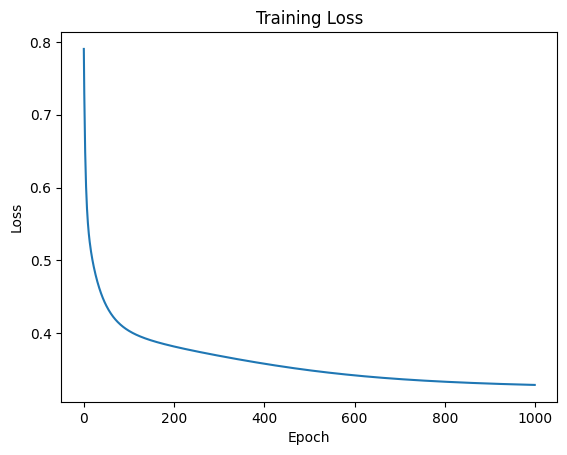

Training Accuracy: 0.8466
Test Accuracy: 0.8506


In [64]:
input_dim = X_train.shape[1]
hidden_dim = 75
output_dim = 1

mlp = MLP(input_dim, hidden_dim, output_dim)
criterion = nn.BCELoss()
optimizer = optim.SGD(mlp.parameters(), lr=0.1)

# Convert data to PyTorch tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).view(-1, 1)

epochs = 1000
losses = []

for epoch in range(epochs):
    # Forward pass
    outputs = mlp(X_train_tensor)
    loss = criterion(outputs, y_train_tensor)
    losses.append(loss.item())

    # Backward pass
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if (epoch + 1) % 100 == 0:
        print(f"Epoch {epoch + 1}/{epochs}, Loss: {loss.item():.4f}")

# Plot training loss
plt.plot(losses)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

# MLP Evaluation
def evaluate_model(model, X, y):
    model.eval()
    with torch.no_grad():
        predictions = model(X) > 0.5
        accuracy = torch.mean((predictions == y).float()).item()
    return accuracy

train_accuracy = evaluate_model(mlp, X_train_tensor, y_train_tensor)
test_accuracy = evaluate_model(mlp, X_test_tensor, y_test_tensor)

print(f"Training Accuracy: {train_accuracy:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

### Fourth Experiment

  - `hidden_dim` is set to 100. 
  - Training accuracy showed no improvement on training accuracy (from 0.8466 to 0.8466).
  - Test accuracy showed no improvement (from 0.8506 to 0.8492).
  - Loss showed small improvement (from 0.3292 to 0.3277).
  - Execution time is longer, from 6.5 seconds to 7.1 seconds.

Epoch 100/1000, Loss: 0.3990
Epoch 200/1000, Loss: 0.3767
Epoch 300/1000, Loss: 0.3639
Epoch 400/1000, Loss: 0.3536
Epoch 500/1000, Loss: 0.3453
Epoch 600/1000, Loss: 0.3390
Epoch 700/1000, Loss: 0.3344
Epoch 800/1000, Loss: 0.3313
Epoch 900/1000, Loss: 0.3292
Epoch 1000/1000, Loss: 0.3277


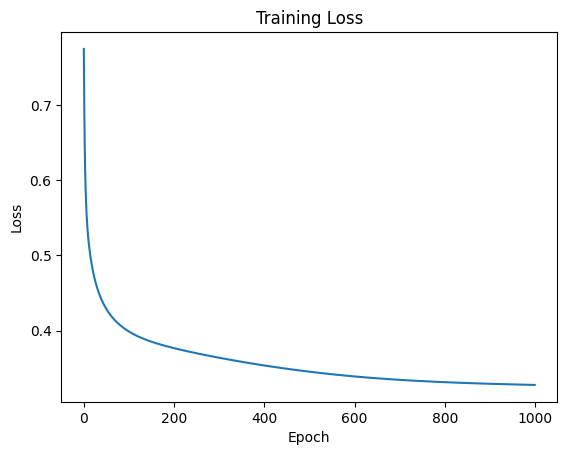

Training Accuracy: 0.8466
Test Accuracy: 0.8492


In [65]:
input_dim = X_train.shape[1]
hidden_dim = 100
output_dim = 1

mlp = MLP(input_dim, hidden_dim, output_dim)
criterion = nn.BCELoss()
optimizer = optim.SGD(mlp.parameters(), lr=0.1)

# Convert data to PyTorch tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).view(-1, 1)

epochs = 1000
losses = []

for epoch in range(epochs):
    # Forward pass
    outputs = mlp(X_train_tensor)
    loss = criterion(outputs, y_train_tensor)
    losses.append(loss.item())

    # Backward pass
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if (epoch + 1) % 100 == 0:
        print(f"Epoch {epoch + 1}/{epochs}, Loss: {loss.item():.4f}")

# Plot training loss
plt.plot(losses)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

# MLP Evaluation
def evaluate_model(model, X, y):
    model.eval()
    with torch.no_grad():
        predictions = model(X) > 0.5
        accuracy = torch.mean((predictions == y).float()).item()
    return accuracy

train_accuracy = evaluate_model(mlp, X_train_tensor, y_train_tensor)
test_accuracy = evaluate_model(mlp, X_test_tensor, y_test_tensor)

print(f"Training Accuracy: {train_accuracy:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

## 2.) Effect of Layers

**What happens to the performance of the neural network when more layers are added to the architecture??**

### First Experiment

- 3 hidden layers are added (`hidden_dim1`, `hidden_dim2`, `hidden_dim3`)
- `ReLU` is used in between hidden layers to introduce non-linearity and help the model learn complex patterns.

In [66]:
class MLP(nn.Module):
    def __init__(self, input_dim, hidden_dim1, hidden_dim2, hidden_dim3, output_dim):
        super(MLP, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, hidden_dim1),
            nn.ReLU(),
            nn.Linear(hidden_dim1, hidden_dim2),
            nn.ReLU(),
            nn.Linear(hidden_dim2, hidden_dim3),
            nn.ReLU(),
            nn.Linear(hidden_dim3, output_dim),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.model(x)

- Neurons of hidden layers are set to 10 as baseline.
- Training accuracy showed small improvement on training accuracy (from 0.8433 to 0.8450).
- Test accuracy showed small improvement (from 0.8463 to 0.8497).
- Loss showed a bit significant improvement (from 0.3343 to 0.3298).
- Execution time is longer, from 1.5 seconds to 3.4 seconds.

Epoch 100/1000, Loss: 0.5419
Epoch 200/1000, Loss: 0.4902
Epoch 300/1000, Loss: 0.4141
Epoch 400/1000, Loss: 0.3798
Epoch 500/1000, Loss: 0.3594
Epoch 600/1000, Loss: 0.3456
Epoch 700/1000, Loss: 0.3381
Epoch 800/1000, Loss: 0.3340
Epoch 900/1000, Loss: 0.3315
Epoch 1000/1000, Loss: 0.3298


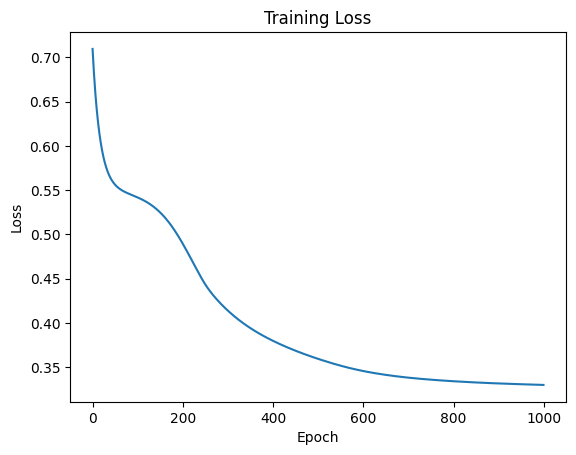

Training Accuracy: 0.8450
Test Accuracy: 0.8497


In [67]:
input_dim = X_train.shape[1]
hidden_dim1 = 10
hidden_dim2 = 10
hidden_dim3 = 10
output_dim = 1

mlp = MLP(input_dim, hidden_dim1, hidden_dim2, hidden_dim3, output_dim)
criterion = nn.BCELoss()
optimizer = optim.SGD(mlp.parameters(), lr=0.1)

# Convert data to PyTorch tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).view(-1, 1)

epochs = 1000
losses = []

for epoch in range(epochs):
    # Forward pass
    outputs = mlp(X_train_tensor)
    loss = criterion(outputs, y_train_tensor)
    losses.append(loss.item())

    # Backward pass
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if (epoch + 1) % 100 == 0:
        print(f"Epoch {epoch + 1}/{epochs}, Loss: {loss.item():.4f}")

# Plot training loss
plt.plot(losses)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

# MLP Evaluation
def evaluate_model(model, X, y):
    model.eval()
    with torch.no_grad():
        predictions = model(X) > 0.5
        accuracy = torch.mean((predictions == y).float()).item()
    return accuracy

train_accuracy = evaluate_model(mlp, X_train_tensor, y_train_tensor)
test_accuracy = evaluate_model(mlp, X_test_tensor, y_test_tensor)

print(f"Training Accuracy: {train_accuracy:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")


### Second Experiment

- 5 hidden layers are added (`hidden_dim1`, `hidden_dim2`, `hidden_dim3`, `hidden_dim4`, `hidden_dim5`)
- `ReLU` is used in between hidden layers to introduce non-linearity and help the model learn complex patterns.

In [68]:
class MLP(nn.Module):
    def __init__(self, input_dim, hidden_dim1, hidden_dim2, hidden_dim3, hidden_dim4, hidden_dim5, output_dim):
        super(MLP, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, hidden_dim1),
            nn.ReLU(),
            nn.Linear(hidden_dim1, hidden_dim2),
            nn.ReLU(),
            nn.Linear(hidden_dim2, hidden_dim3),
            nn.ReLU(),
            nn.Linear(hidden_dim3, hidden_dim4),
            nn.ReLU(),
            nn.Linear(hidden_dim4, hidden_dim5),
            nn.ReLU(),
            nn.Linear(hidden_dim5, output_dim),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.model(x)

- Neurons of hidden layers are set to 10 as baseline.
- Training accuracy showed small improvement on training accuracy (from 0.8450 to 0.8460).
- Test accuracy showed no improvement (from 0.8497 to 0.8494).
- Loss showed small improvement (from 0.3298 to 0.3288).
- Execution time is longer, from 3.4 seconds to 5.0 seconds.

Epoch 100/1000, Loss: 0.5490
Epoch 200/1000, Loss: 0.5372
Epoch 300/1000, Loss: 0.4668
Epoch 400/1000, Loss: 0.4119
Epoch 500/1000, Loss: 0.3881
Epoch 600/1000, Loss: 0.3632
Epoch 700/1000, Loss: 0.3428
Epoch 800/1000, Loss: 0.3352
Epoch 900/1000, Loss: 0.3314
Epoch 1000/1000, Loss: 0.3288


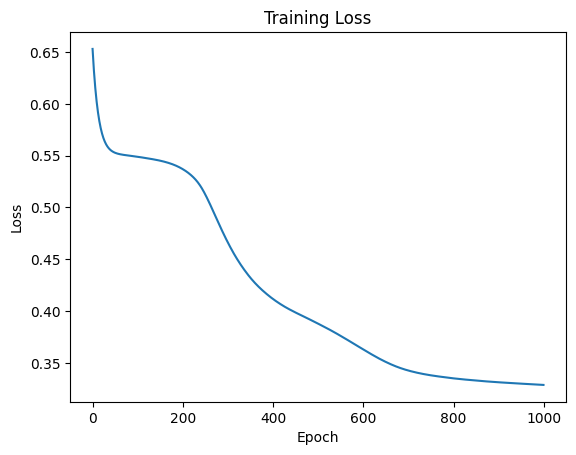

Training Accuracy: 0.8460
Test Accuracy: 0.8494


In [69]:
input_dim = X_train.shape[1]
hidden_dim1 = 10
hidden_dim2 = 10
hidden_dim3 = 10
hidden_dim4 = 10
hidden_dim5 = 10
output_dim = 1

mlp = MLP(input_dim, hidden_dim1, hidden_dim2, hidden_dim3, hidden_dim4, hidden_dim5,output_dim)
criterion = nn.BCELoss()
optimizer = optim.SGD(mlp.parameters(), lr=0.1)

# Convert data to PyTorch tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).view(-1, 1)

epochs = 1000
losses = []

for epoch in range(epochs):
    # Forward pass
    outputs = mlp(X_train_tensor)
    loss = criterion(outputs, y_train_tensor)
    losses.append(loss.item())

    # Backward pass
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if (epoch + 1) % 100 == 0:
        print(f"Epoch {epoch + 1}/{epochs}, Loss: {loss.item():.4f}")

# Plot training loss
plt.plot(losses)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

# MLP Evaluation
def evaluate_model(model, X, y):
    model.eval()
    with torch.no_grad():
        predictions = model(X) > 0.5
        accuracy = torch.mean((predictions == y).float()).item()
    return accuracy

train_accuracy = evaluate_model(mlp, X_train_tensor, y_train_tensor)
test_accuracy = evaluate_model(mlp, X_test_tensor, y_test_tensor)

print(f"Training Accuracy: {train_accuracy:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

### Third Experiment

- 7 hidden layers are added (`hidden_dim1`, `hidden_dim2`, `hidden_dim3`, `hidden_dim4`, `hidden_dim5`, `hidden_dim6`, `hidden_dim7`)
- `ReLU` is used in between hidden layers to introduce non-linearity and help the model learn complex patterns.

In [70]:
class MLP(nn.Module):
    def __init__(self, input_dim, hidden_dim1, hidden_dim2, hidden_dim3, hidden_dim4, hidden_dim5, hidden_dim6, hidden_dim7, output_dim):
        super(MLP, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, hidden_dim1),
            nn.ReLU(),
            nn.Linear(hidden_dim1, hidden_dim2),
            nn.ReLU(),
            nn.Linear(hidden_dim2, hidden_dim3),
            nn.ReLU(),
            nn.Linear(hidden_dim3, hidden_dim4),
            nn.ReLU(),
            nn.Linear(hidden_dim4, hidden_dim5),
            nn.ReLU(),
            nn.Linear(hidden_dim5, hidden_dim6),
            nn.ReLU(),
            nn.Linear(hidden_dim6, hidden_dim7),
            nn.ReLU(),
            nn.Linear(hidden_dim7, output_dim),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.model(x)

- Neurons of hidden layers are set to 10 as baseline.
- Training accuracy showed no improvement on training accuracy (from 0.8460 to 0.7593).
- Test accuracy showed no improvement (from 0.8494 to 0.7588).
- Loss showed no improvement (from 0.3288 to 0.5519).
- Execution time is longer, from 5.0 seconds to 6.7 seconds.

Epoch 100/1000, Loss: 0.5522
Epoch 200/1000, Loss: 0.5519
Epoch 300/1000, Loss: 0.5519
Epoch 400/1000, Loss: 0.5519
Epoch 500/1000, Loss: 0.5519
Epoch 600/1000, Loss: 0.5519
Epoch 700/1000, Loss: 0.5519
Epoch 800/1000, Loss: 0.5519
Epoch 900/1000, Loss: 0.5519
Epoch 1000/1000, Loss: 0.5519


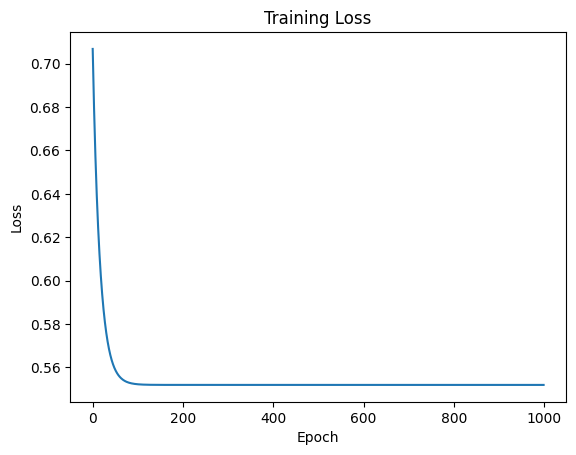

Training Accuracy: 0.7593
Test Accuracy: 0.7588


In [71]:
input_dim = X_train.shape[1]
hidden_dim1 = 10
hidden_dim2 = 10
hidden_dim3 = 10
hidden_dim4 = 10
hidden_dim5 = 10
hidden_dim6 = 10
hidden_dim7 = 10
output_dim = 1

mlp = MLP(input_dim, hidden_dim1, hidden_dim2, hidden_dim3, hidden_dim4, hidden_dim5, hidden_dim6, hidden_dim7, output_dim)
criterion = nn.BCELoss()
optimizer = optim.SGD(mlp.parameters(), lr=0.1)

# Convert data to PyTorch tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).view(-1, 1)

epochs = 1000
losses = []

for epoch in range(epochs):
    # Forward pass
    outputs = mlp(X_train_tensor)
    loss = criterion(outputs, y_train_tensor)
    losses.append(loss.item())

    # Backward pass
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if (epoch + 1) % 100 == 0:
        print(f"Epoch {epoch + 1}/{epochs}, Loss: {loss.item():.4f}")

# Plot training loss
plt.plot(losses)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

# MLP Evaluation
def evaluate_model(model, X, y):
    model.eval()
    with torch.no_grad():
        predictions = model(X) > 0.5
        accuracy = torch.mean((predictions == y).float()).item()
    return accuracy

train_accuracy = evaluate_model(mlp, X_train_tensor, y_train_tensor)
test_accuracy = evaluate_model(mlp, X_test_tensor, y_test_tensor)

print(f"Training Accuracy: {train_accuracy:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

## 3.) Loss Function

**What other loss functions are appropriate for this problem, and why?**

`BCEWithLogitsLoss`
- Combines sigmoid function and BCE into a single function
- More numerically stable than using a plain Sigmoid followed by a BCELoss (PyTorch.org)

Epoch 100/1000, Loss: 0.4523
Epoch 200/1000, Loss: 0.3931
Epoch 300/1000, Loss: 0.3738
Epoch 400/1000, Loss: 0.3635
Epoch 500/1000, Loss: 0.3559
Epoch 600/1000, Loss: 0.3500
Epoch 700/1000, Loss: 0.3454
Epoch 800/1000, Loss: 0.3418
Epoch 900/1000, Loss: 0.3389
Epoch 1000/1000, Loss: 0.3365


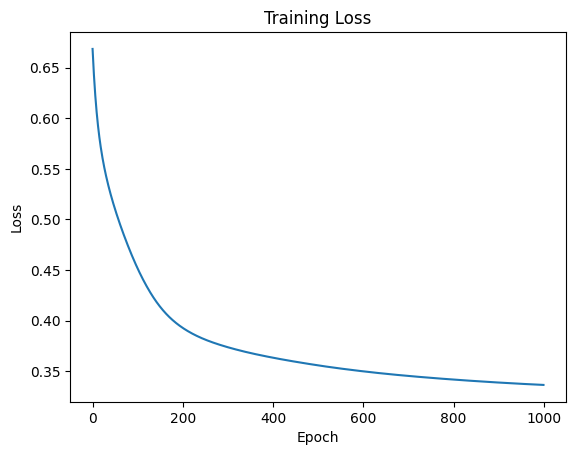

Training Accuracy: 0.8411
Test Accuracy: 0.8419


In [72]:
class MLP(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super(MLP, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, output_dim)
            # removed sigmoid function here
        )

    def forward(self, x):
        return self.model(x)
    
input_dim = X_train.shape[1]
hidden_dim = 10
output_dim = 1

mlp = MLP(input_dim, hidden_dim, output_dim) 
criterion = nn.BCEWithLogitsLoss() # changed nn.BCELoss() to nn.BCEWithLogitsLoss()
optimizer = optim.SGD(mlp.parameters(), lr=0.1)

# Convert data to PyTorch tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).view(-1, 1)

epochs = 1000
losses = []

for epoch in range(epochs):
    # Forward pass
    outputs = mlp(X_train_tensor)
    loss = criterion(outputs, y_train_tensor)
    losses.append(loss.item())

    # Backward pass
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if (epoch + 1) % 100 == 0:
        print(f"Epoch {epoch + 1}/{epochs}, Loss: {loss.item():.4f}")

# Plot training loss
plt.plot(losses)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

def evaluate_model(model, X, y):
    model.eval()
    with torch.no_grad():
        predictions = torch.sigmoid(model(X)) > 0.5 # applied sigmoid function for raw output conversion into probabilities
        accuracy = torch.mean((predictions == y).float()).item()
    return accuracy

train_accuracy = evaluate_model(mlp, X_train_tensor, y_train_tensor)
test_accuracy = evaluate_model(mlp, X_test_tensor, y_test_tensor)

print(f"Training Accuracy: {train_accuracy:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

## 4.) Layer-Specific Loss

**Can different loss functions be used per layer? If so, how would it work?**

Yes, different loss functions can be used per layer. However, it would require multiple steps to integrate it. (Refer to written report for details)



## 5.) Training Loop

**Which part of the training loop backpropagates the gradients backward? Which part handles the forward pass?**

Based on each MLP Training code blocks:

    for epoch in range(epochs):
        # Forward pass
        outputs = mlp(X_train_tensor)
        loss = criterion(outputs, y_train_tensor)
        losses.append(loss.item())

This part handles the forward pass while;

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

This part backpropagates the gradients backward.

## 6.) Evaluation Metrics

**Can metrics other than accuracy be used to evaluate the model? If so, which ones are most appropriate for this problem?**

- Yes, metrics such as Precision, Recall, F1-score, AUC-ROC, and Confustion Matrix can ba used. 
- AUC-ROC, and F1-score are most appropriate for this problem due to imbalanced dataset.
- We can still use Precision, Recall, and Confusion Matrix to determine and analyze the false positives and false negatives.

Epoch 100/1000, Loss: 0.4612
Epoch 200/1000, Loss: 0.4026
Epoch 300/1000, Loss: 0.3829
Epoch 400/1000, Loss: 0.3725
Epoch 500/1000, Loss: 0.3653
Epoch 600/1000, Loss: 0.3595
Epoch 700/1000, Loss: 0.3548
Epoch 800/1000, Loss: 0.3507
Epoch 900/1000, Loss: 0.3470
Epoch 1000/1000, Loss: 0.3437


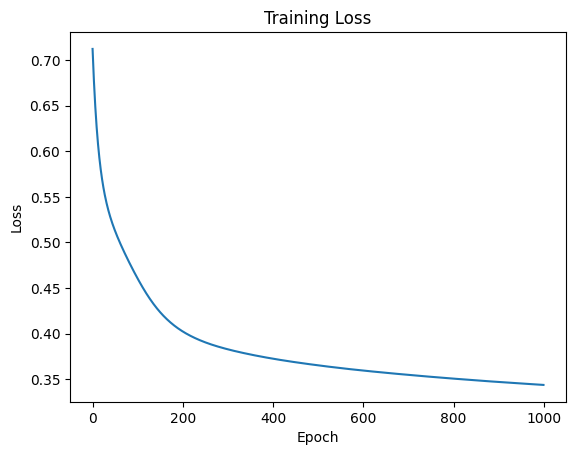

Testing Set Evaluation
Accuracy: 0.8400
Precision: 0.7381
Recall: 0.5220
F1-Score: 0.6115
AUC-ROC: 0.8931
Confusion Matrix:
[[4651  291]
 [ 751  820]]


Training Set Evaluation
Accuracy: 0.8378
Precision: 0.7318
Recall: 0.5148
F1-Score: 0.6044
AUC-ROC: 0.8894
Confusion Matrix:
[[18595  1183]
 [ 3042  3228]]


In [73]:
class MLP(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super(MLP, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, output_dim),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.model(x)
    
input_dim = X_train.shape[1]
hidden_dim = 10
output_dim = 1

mlp = MLP(input_dim, hidden_dim, output_dim)
criterion = nn.BCELoss()
optimizer = optim.SGD(mlp.parameters(), lr=0.1)

# Convert data to PyTorch tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).view(-1, 1)

epochs = 1000
losses = []

for epoch in range(epochs):
    # Forward pass
    outputs = mlp(X_train_tensor)
    loss = criterion(outputs, y_train_tensor)
    losses.append(loss.item())

    # Backward pass
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if (epoch + 1) % 100 == 0:
        print(f"Epoch {epoch + 1}/{epochs}, Loss: {loss.item():.4f}")

# Plot training loss
plt.plot(losses)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()
    
def evaluate_model_extended(model, X, y):
    model.eval()
    with torch.no_grad():
        probabilities = (model(X)).cpu().numpy().flatten()
        predictions = (probabilities > 0.5).astype(int)
        actual_y = y.cpu().numpy().flatten()
        
    accuracy = accuracy_score(actual_y, predictions)
    precision = precision_score(actual_y, predictions)
    recall = recall_score(actual_y, predictions)
    f1 = f1_score(actual_y, predictions)
    roc_auc = roc_auc_score(actual_y, probabilities)
    conf_matrix = confusion_matrix(actual_y, predictions)


    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-Score: {f1:.4f}")    
    print(f"AUC-ROC: {roc_auc:.4f}")
    print(f"Confusion Matrix:\n{conf_matrix}")

print("Testing Set Evaluation")
evaluate_model_extended(mlp, X_test_tensor, y_test_tensor)

print("\n")
print("Training Set Evaluation")
evaluate_model_extended(mlp, X_train_tensor, y_train_tensor)


## 7.) Learning Rate Impact

**What is the impact of the learning rate on the performance of the neural network? Experiment with different values.**

### First Experiment (smaller learning rate)
- Learning rate = 0.01
- Training accuracy showed no improvement (from 0.8433 to 0.7607).
- Test accuracy showed no improvement (from 0.8463 to 0.7603).
- Loss showed no improvement (from 0.3343 to 0.4473).
- Execution time showed no significant difference, from 1.5 seconds to 1.8 seconds.

Epoch 100/1000, Loss: 0.5990
Epoch 200/1000, Loss: 0.5541
Epoch 300/1000, Loss: 0.5254
Epoch 400/1000, Loss: 0.5051
Epoch 500/1000, Loss: 0.4899
Epoch 600/1000, Loss: 0.4780
Epoch 700/1000, Loss: 0.4683
Epoch 800/1000, Loss: 0.4603
Epoch 900/1000, Loss: 0.4534
Epoch 1000/1000, Loss: 0.4473


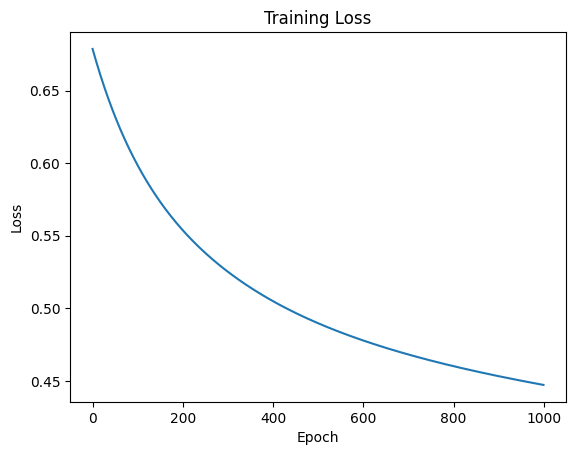

Training Accuracy: 0.7607
Test Accuracy: 0.7603


In [74]:
class MLP(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super(MLP, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, output_dim),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.model(x)
    
input_dim = X_train.shape[1]
hidden_dim = 10
output_dim = 1

mlp = MLP(input_dim, hidden_dim, output_dim) 
criterion = nn.BCELoss()
optimizer = optim.SGD(mlp.parameters(), lr=0.01)

# Convert data to PyTorch tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).view(-1, 1)

epochs = 1000
losses = []

for epoch in range(epochs):
    # Forward pass
    outputs = mlp(X_train_tensor)
    loss = criterion(outputs, y_train_tensor)
    losses.append(loss.item())

    # Backward pass
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if (epoch + 1) % 100 == 0:
        print(f"Epoch {epoch + 1}/{epochs}, Loss: {loss.item():.4f}")

# Plot training loss
plt.plot(losses)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

def evaluate_model(model, X, y):
    model.eval()
    with torch.no_grad():
        predictions = model(X) > 0.5
        accuracy = torch.mean((predictions == y).float()).item()
    return accuracy

train_accuracy = evaluate_model(mlp, X_train_tensor, y_train_tensor)
test_accuracy = evaluate_model(mlp, X_test_tensor, y_test_tensor)

print(f"Training Accuracy: {train_accuracy:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

### Second Experiment (smaller learning rate)
- learning rate = 0.001
- Training accuracy showed no improvement (from 0.7607 to 0.7586).
- Test accuracy showed no improvement (from 0.7603 to 0.7585).
- Loss showed no improvement (from 0.4473 to 0.6133).
- Execution time showed no significant difference, from 1.8 seconds to 1.8 seconds.

Epoch 100/1000, Loss: 0.6551
Epoch 200/1000, Loss: 0.6493
Epoch 300/1000, Loss: 0.6439
Epoch 400/1000, Loss: 0.6388
Epoch 500/1000, Loss: 0.6340
Epoch 600/1000, Loss: 0.6294
Epoch 700/1000, Loss: 0.6251
Epoch 800/1000, Loss: 0.6210
Epoch 900/1000, Loss: 0.6171
Epoch 1000/1000, Loss: 0.6133


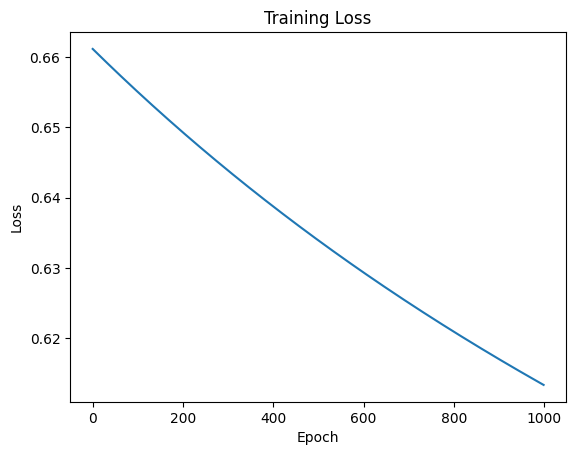

Training Accuracy: 0.7586
Test Accuracy: 0.7585


In [75]:
class MLP(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super(MLP, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, output_dim),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.model(x)
    
input_dim = X_train.shape[1]
hidden_dim = 10
output_dim = 1

mlp = MLP(input_dim, hidden_dim, output_dim) 
criterion = nn.BCELoss()
optimizer = optim.SGD(mlp.parameters(), lr=0.001)

# Convert data to PyTorch tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).view(-1, 1)

epochs = 1000
losses = []

for epoch in range(epochs):
    # Forward pass
    outputs = mlp(X_train_tensor)
    loss = criterion(outputs, y_train_tensor)
    losses.append(loss.item())

    # Backward pass
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if (epoch + 1) % 100 == 0:
        print(f"Epoch {epoch + 1}/{epochs}, Loss: {loss.item():.4f}")

# Plot training loss
plt.plot(losses)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

def evaluate_model(model, X, y):
    model.eval()
    with torch.no_grad():
        predictions = model(X) > 0.5
        accuracy = torch.mean((predictions == y).float()).item()
    return accuracy

train_accuracy = evaluate_model(mlp, X_train_tensor, y_train_tensor)
test_accuracy = evaluate_model(mlp, X_test_tensor, y_test_tensor)

print(f"Training Accuracy: {train_accuracy:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

### Third Experiment (smaller learning rate)
- Learning Rate = 0.0001
- Training accuracy showed no improvement (from 0.7586 to 0.5448).
- Test accuracy showed no improvement (from 0.7585 to 0.5406).
- Loss showed no improvement (from 0.6133 to 0.6943).
- Execution time showed no significant difference, from 1.8 seconds to 1.9 seconds.

Epoch 100/1000, Loss: 0.7077
Epoch 200/1000, Loss: 0.7062
Epoch 300/1000, Loss: 0.7047
Epoch 400/1000, Loss: 0.7031
Epoch 500/1000, Loss: 0.7016
Epoch 600/1000, Loss: 0.7002
Epoch 700/1000, Loss: 0.6987
Epoch 800/1000, Loss: 0.6972
Epoch 900/1000, Loss: 0.6958
Epoch 1000/1000, Loss: 0.6943


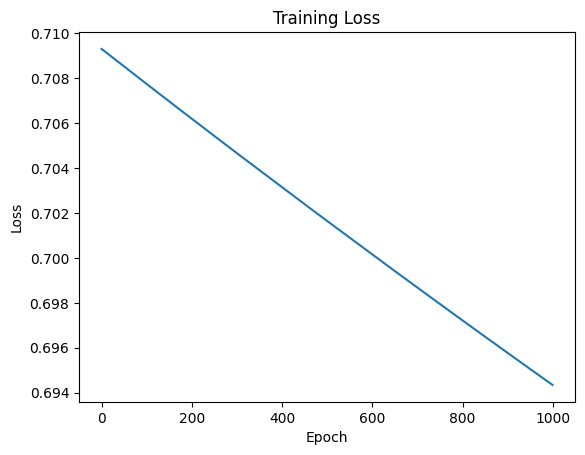

Training Accuracy: 0.5448
Test Accuracy: 0.5406


In [76]:
class MLP(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super(MLP, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, output_dim),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.model(x)
    
input_dim = X_train.shape[1]
hidden_dim = 10
output_dim = 1

mlp = MLP(input_dim, hidden_dim, output_dim) 
criterion = nn.BCELoss()
optimizer = optim.SGD(mlp.parameters(), lr=0.0001)

# Convert data to PyTorch tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).view(-1, 1)

epochs = 1000
losses = []

for epoch in range(epochs):
    # Forward pass
    outputs = mlp(X_train_tensor)
    loss = criterion(outputs, y_train_tensor)
    losses.append(loss.item())

    # Backward pass
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if (epoch + 1) % 100 == 0:
        print(f"Epoch {epoch + 1}/{epochs}, Loss: {loss.item():.4f}")

# Plot training loss
plt.plot(losses)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

def evaluate_model(model, X, y):
    model.eval()
    with torch.no_grad():
        predictions = model(X) > 0.5
        accuracy = torch.mean((predictions == y).float()).item()
    return accuracy

train_accuracy = evaluate_model(mlp, X_train_tensor, y_train_tensor)
test_accuracy = evaluate_model(mlp, X_test_tensor, y_test_tensor)

print(f"Training Accuracy: {train_accuracy:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

### Fourth Experiment (bigger learning rate)
- Learning Rate = 1
- Training accuracy showed small improvement (from 0.8433 to 0.8494).
- Test accuracy showed a bit significant improvement (from 0.8463 to 0.8514).
- Loss showed small improvement (from 0.3343 to 0.3209).
- Execution time showed no difference, from 1.9 seconds to 1.9 seconds.

Epoch 100/1000, Loss: 0.3355
Epoch 200/1000, Loss: 0.3278
Epoch 300/1000, Loss: 0.3256
Epoch 400/1000, Loss: 0.3245
Epoch 500/1000, Loss: 0.3238
Epoch 600/1000, Loss: 0.3232
Epoch 700/1000, Loss: 0.3224
Epoch 800/1000, Loss: 0.3219
Epoch 900/1000, Loss: 0.3214
Epoch 1000/1000, Loss: 0.3209


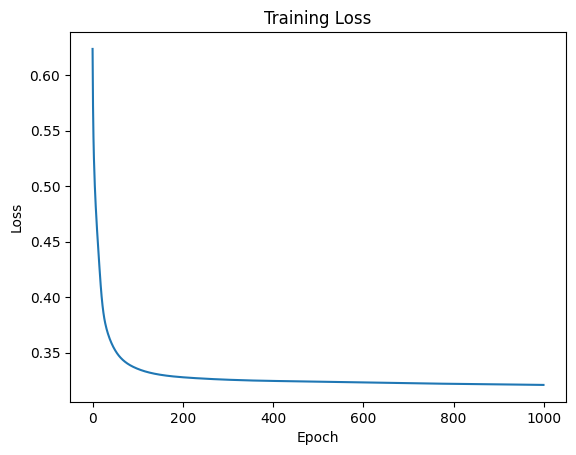

Training Accuracy: 0.8494
Test Accuracy: 0.8514


In [77]:
class MLP(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super(MLP, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, output_dim),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.model(x)
    
input_dim = X_train.shape[1]
hidden_dim = 10
output_dim = 1

mlp = MLP(input_dim, hidden_dim, output_dim) 
criterion = nn.BCELoss()
optimizer = optim.SGD(mlp.parameters(), lr=1)

# Convert data to PyTorch tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).view(-1, 1)

epochs = 1000
losses = []

for epoch in range(epochs):
    # Forward pass
    outputs = mlp(X_train_tensor)
    loss = criterion(outputs, y_train_tensor)
    losses.append(loss.item())

    # Backward pass
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if (epoch + 1) % 100 == 0:
        print(f"Epoch {epoch + 1}/{epochs}, Loss: {loss.item():.4f}")

# Plot training loss
plt.plot(losses)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

def evaluate_model(model, X, y):
    model.eval()
    with torch.no_grad():
        predictions = model(X) > 0.5
        accuracy = torch.mean((predictions == y).float()).item()
    return accuracy

train_accuracy = evaluate_model(mlp, X_train_tensor, y_train_tensor)
test_accuracy = evaluate_model(mlp, X_test_tensor, y_test_tensor)

print(f"Training Accuracy: {train_accuracy:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

### Fifth Experiment (bigger learning rate)
- Learning Rate = 10
- Training accuracy showed no improvement (from 0.8494 to 0.8328).
- Test accuracy showed no improvement (from 0.8514 to 0.8339).
- Loss showed no improvement (from 0.3209 to 0.3367).
- Execution time showed no significant difference, from 1.9 seconds to 2.0 seconds.

Epoch 100/1000, Loss: 0.3650
Epoch 200/1000, Loss: 0.3554
Epoch 300/1000, Loss: 0.3447
Epoch 400/1000, Loss: 0.3420
Epoch 500/1000, Loss: 0.3405
Epoch 600/1000, Loss: 0.3394
Epoch 700/1000, Loss: 0.3390
Epoch 800/1000, Loss: 0.3377
Epoch 900/1000, Loss: 0.3375
Epoch 1000/1000, Loss: 0.3367


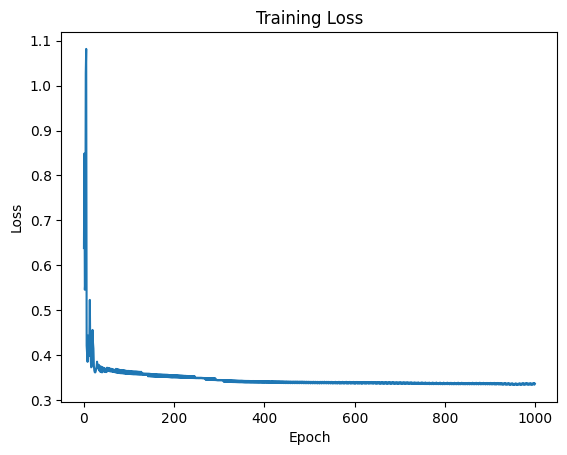

Training Accuracy: 0.8328
Test Accuracy: 0.8339


In [78]:
class MLP(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super(MLP, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, output_dim),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.model(x)
    
input_dim = X_train.shape[1]
hidden_dim = 10
output_dim = 1

mlp = MLP(input_dim, hidden_dim, output_dim) 
criterion = nn.BCELoss()
optimizer = optim.SGD(mlp.parameters(), lr=10)

# Convert data to PyTorch tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).view(-1, 1)

epochs = 1000
losses = []

for epoch in range(epochs):
    # Forward pass
    outputs = mlp(X_train_tensor)
    loss = criterion(outputs, y_train_tensor)
    losses.append(loss.item())

    # Backward pass
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if (epoch + 1) % 100 == 0:
        print(f"Epoch {epoch + 1}/{epochs}, Loss: {loss.item():.4f}")

# Plot training loss
plt.plot(losses)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

def evaluate_model(model, X, y):
    model.eval()
    with torch.no_grad():
        predictions = model(X) > 0.5
        accuracy = torch.mean((predictions == y).float()).item()
    return accuracy

train_accuracy = evaluate_model(mlp, X_train_tensor, y_train_tensor)
test_accuracy = evaluate_model(mlp, X_test_tensor, y_test_tensor)

print(f"Training Accuracy: {train_accuracy:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

## 8.) Training Time
**How does the training time change when you tweak the number of layers, neurons, or other architectural parameters?**
 
- More *layers*, longer training time.
- More *neurons*, longer training time.
- Number of *learning rate* does not affect training time.